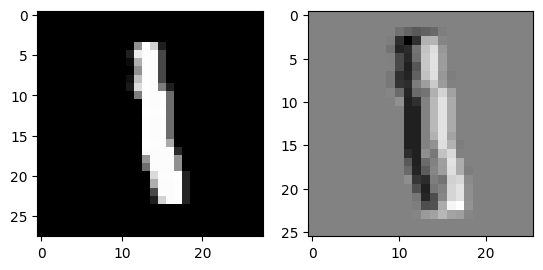

In [3]:
from PIL import Image
from matplotlib import pyplot as plt
import torch
from torchvision.transforms.functional import to_tensor

image = Image.open("img.png") # прочитайте изображение img.png
image_tensor = to_tensor(image) # тензор [1, 28, 28]

# добавлено ещё одно измерение, чтобы получить [1, 1, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 

kernel = torch.Tensor([[[[3, 0, 3],
                         [10, 0, -10],
                         [-3, 0, -3]]]])

result = torch.nn.functional.conv2d(image_tensor, kernel)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

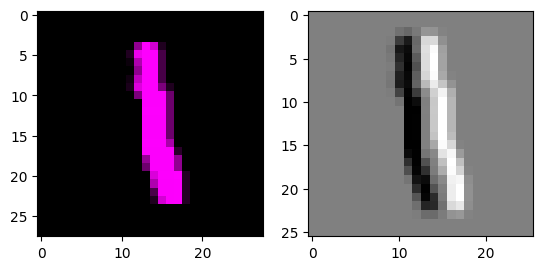

In [5]:
from PIL import Image
from matplotlib import pyplot as plt
import torch
import numpy as np
from torchvision.transforms.functional import to_tensor

image = Image.open("img_colored.png") # прочитайте изображение img_colored.png
image_tensor = to_tensor(image) # тензор [1, 3, 28, 28]
# добавлено еще одно измерение, чтобы получить [1, 3, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 

kernel = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                   [10, 0, -10],
                   [3, 0, -3]])

kernel_3D = np.tile(kernel, (3, 1, 1)) # ваш код для трехмерного фильтра вертикальных линий
kernel_3D = torch.Tensor(kernel_3D)
kernel_3D = kernel_3D.unsqueeze(0)

result = torch.nn.functional.conv2d(image_tensor, kernel_3D) # в этой переменной сохраните итоговую карту признаков

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

In [7]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms.functional import to_tensor
import torch.nn as nn

image = Image.open("img_colored.png") # прочитайте изображение img_colored.png
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

con = nn.Conv2d(3, 20, 3)

result = con(image_tensor).detach()

print("Размерность тензора: ", result.shape)

Размерность тензора:  torch.Size([1, 20, 26, 26])


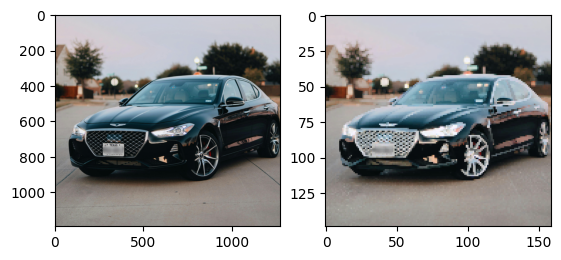

In [8]:
from matplotlib import pyplot as plt

image = Image.open("car.png") # переменная для загрузки car.png с помощью PIL
image_tensor = to_tensor(image) # переменная для изображения, преобразованного в тензор
image_tensor = image_tensor.unsqueeze(0)

pool = nn.MaxPool2d(8, stride=8)
# ваш код для приведения тензора изображения к подходящей размерности
result = pool(image_tensor).detach() # переменная для результатов макс-пулинга

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0].permute(1, 2, 0))